In [75]:
import os
import subprocess
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')
print("Google Drive is now connected!")

# Step 2: Tell the user where we expect the ZIP to be
print("\nWe will look for your ZIP inside:")
print("  /content/drive/MyDrive/MultiClass_Dataset/")

# Step 3: Check if that folder even exists on Drive
xray_folder = '/content/drive/MyDrive/MultiClass_Dataset'

if os.path.exists(xray_folder):
    print(" 'MultiClass_Dataset' folder found on Drive!")
else:
    print(" 'MultiClass_Dataset' folder NOT found on Drive!")
    print("   Check your Google Drive folder name carefully.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive is now connected!

We will look for your ZIP inside:
  /content/drive/MyDrive/MultiClass_Dataset/
 'MultiClass_Dataset' folder found on Drive!


In [76]:

import os

# The Drive folder we want to search inside
xray_folder = '/content/drive/MyDrive/MultiClass_Dataset/MultiClass_Dataset'

# This variable will store the ZIP path once we find it
drive_zip = None

print("Searching for a .zip file inside 'X_Ray Dataset'...")

# os.walk() goes through every folder and sub-folder one by one
for current_folder, sub_folders, file_names in os.walk(xray_folder):

    # Look at each file in the current folder
    for filename in file_names:

        # Check if this file is a ZIP file
        if filename.endswith('.zip'):

            # Build the full path to the ZIP file
            drive_zip = os.path.join(current_folder, filename)

            # Get the file size so we can confirm it looks right
            size_in_bytes = os.path.getsize(drive_zip)
            size_in_gb    = size_in_bytes / (1024 * 1024 * 1024)

            print(f"Found ZIP file!")
            print(f"Name : {filename}")
            print(f"Path : {drive_zip}")
            print(f"Size : {size_in_gb:.2f} GB")

            # Stop searching — we found it
            break

    # If we already found the ZIP, stop the outer loop too
    if drive_zip is not None:
        break

# Final check — did we find it?
if drive_zip is None:
    print("No ZIP file found in 'X_Ray Dataset'!")
    print("\nWhat IS inside the folder:")

    # Show everything inside so the user can investigate
    for current_folder, sub_folders, file_names in os.walk(xray_folder):
        for filename in file_names:
            full_path = os.path.join(current_folder, filename)
            size_mb   = os.path.getsize(full_path) / (1024 * 1024)
            print(f"{full_path}  ({size_mb:.1f} MB)")

    # Stop the notebook here — no point continuing without the ZIP
    raise FileNotFoundError("Cannot continue without the ZIP file!")

print("\nZIP file located! Ready for Cell 3.")

Searching for a .zip file inside 'X_Ray Dataset'...
Found ZIP file!
Name : MultiClass.zip
Path : /content/drive/MyDrive/MultiClass_Dataset/MultiClass_Dataset/MultiClass.zip
Size : 11.35 GB

ZIP file located! Ready for Cell 3.


In [77]:
import os
import subprocess

extract_path = '/content/dataset/'

# These two paths must exist after a successful extraction
raw_check = '/content/dataset/MultiClass/MultiClass_Dataset'
csv_check = '/content/dataset/MultiClass/cleaned_multiclass.csv'

print("STEP 1: Checking if dataset is already extracted on Colab disk...")

# Check if both the images folder AND the CSV file already exist
raw_ready = os.path.exists(raw_check)
csv_ready = os.path.exists(csv_check)

if raw_ready and csv_ready:
    # Great — nothing to do! Skip the extraction.
    print(f"Images folder : {raw_check}")
    print(f"CSV file      : {csv_check}")

else:
    # Not found — we need to extract the ZIP now
    print("STEP 2: Starting extraction from Google Drive...")


    # Create the destination folder if it does not exist yet
    os.makedirs(extract_path, exist_ok=True)

    # Run the unzip command
    result = subprocess.run(
        ['unzip', '-o', '-q', drive_zip, '-d', extract_path],
        capture_output=True,
        text=True
    )

    # Check if unzip worked correctly
    # return code 0 means success, anything else is an error
    if result.returncode != 0:
        print("Extraction FAILED!")
        print(f"   Error message: {result.stderr}")
        raise RuntimeError("Unzip failed! See the error message above.")
    else:
        print("Extraction finished!")

# STEP 3: Verify the extracted folder structure
print(f"Looking inside: {extract_path}\n")

if os.path.exists(extract_path):

    # Walk through up to 4 levels deep only
    for current_folder, sub_folders, file_names in os.walk(extract_path):

        # Calculate how deep we are (0 = top level, 1 = one level down, etc.)
        depth = current_folder.replace(extract_path, '').count(os.sep)

        # Stop printing if we are deeper than 4 levels
        if depth > 4:
            continue

        # Build an indent string so the output looks like a tree
        indent       = '    ' * depth
        folder_name  = os.path.basename(current_folder)
        num_files    = len(file_names)

        print(f"{indent}{folder_name}/   ({num_files} files)")

else:
    print("/content/dataset/ is still empty after extraction!")
    print("   Something went wrong. Please re-run Cell 3.")

STEP 1: Checking if dataset is already extracted on Colab disk...
Images folder : /content/dataset/MultiClass/MultiClass_Dataset
CSV file      : /content/dataset/MultiClass/cleaned_multiclass.csv
Looking inside: /content/dataset/

/   (0 files)
MultiClass/   (1 files)
    MultiClass_Dataset/   (0 files)
        Nodule/   (2300 files)
        Edema/   (2300 files)
        Pneumothorax/   (2300 files)
        Pneumonia/   (2300 files)
        Atelectasis/   (2300 files)
        Consolidation/   (2300 files)
        Emphysema/   (2300 files)
        No Finding/   (2300 files)
        Mass/   (2300 files)
        Infiltration/   (2300 files)
        Cardiomegaly/   (2300 files)
        Effusion/   (2299 files)
        Pleural_Thickening/   (2300 files)


In [53]:
import os, torch

CSV_PATH    = '/content/dataset/MultiClass/cleaned_multiclass.csv'
IMAGES_ROOT = '/content/dataset/MultiClass/MultiClass_Dataset/'
SAVE_PATH   = '/content/drive/MyDrive/model_output/DenseNet121_V6.pt'
CHECKPOINT_PATH = '/content/drive/MyDrive/model_output/DenseNet121_V6.pt'

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA L4


Total rows in CSV : 29899
Columns           : ['Image Index', 'Finding Labels', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position']

Class distribution (all classes):
Finding Labels
Cardiomegaly          2300
Emphysema             2300
No Finding            2300
Infiltration          2300
Mass                  2300
Pleural_Thickening    2300
Nodule                2300
Atelectasis           2300
Pneumothorax          2300
Edema                 2300
Pneumonia             2300
Consolidation         2300
Effusion              2299
Name: count, dtype: int64


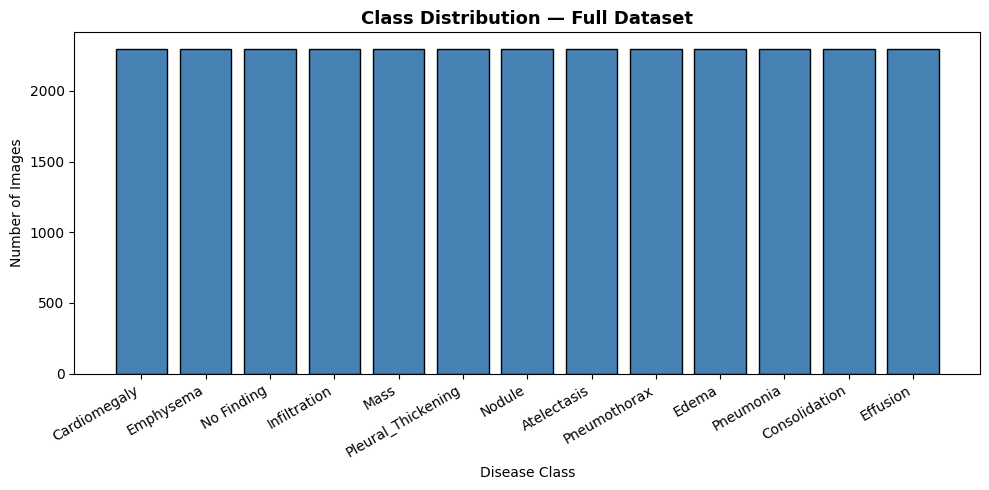

 Plot saved: class distribution chart


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

df_all = pd.read_csv(CSV_PATH)
print(f"Total rows in CSV : {len(df_all)}")
print(f"Columns           : {list(df_all.columns)}")
print("\nClass distribution (all classes):")
print(df_all['Finding Labels'].value_counts())

fig, ax = plt.subplots(figsize=(10, 5))
counts = df_all['Finding Labels'].value_counts()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black')
ax.set_title('Class Distribution — Full Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Disease Class')
ax.set_ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/content/distribution_before.png', dpi=150)
plt.show()
print(" Plot saved: class distribution chart")

In [55]:
from sklearn.model_selection import train_test_split

SELECTED_DISEASES = [
    'Pneumonia',
    'Cardiomegaly',
    'Pneumothorax',
    'Mass',
    'Emphysema',
    'Atelectasis',
]
NUM_CLASSES = len(SELECTED_DISEASES)

df = df_all[df_all['Finding Labels'].isin(SELECTED_DISEASES)].copy()
df = df.reset_index(drop=True)

label_map  = {disease: idx for idx, disease in enumerate(SELECTED_DISEASES)}
df['label'] = df['Finding Labels'].map(label_map)

print(f"Total images (6 classes): {len(df)}")
print(df['Finding Labels'].value_counts())

# 70% train / 15% val / 15% test
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain : {len(train_df)} images")
print(f"Val   : {len(val_df)} images")
print(f"Test  : {len(test_df)} images")
print("done!")

Total images (6 classes): 13800
Finding Labels
Cardiomegaly    2300
Emphysema       2300
Mass            2300
Atelectasis     2300
Pneumothorax    2300
Pneumonia       2300
Name: count, dtype: int64

Train : 9660 images
Val   : 2070 images
Test  : 2070 images
done!


In [66]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Build image path lookup (fast O(1) access)
print("Building image path lookup dictionary...")
image_path_dict = {}
for root_dir, sub_dirs, files in os.walk(IMAGES_ROOT):
    for fname in files:
        if fname.endswith('.png'):
            image_path_dict[fname] = os.path.join(root_dir, fname)
print(f"  Found {len(image_path_dict)} images in dictionary")

# ── Custom Dataset ────────────────────────────────────────────────
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_dict, transform=None):
        self.df         = dataframe
        self.image_dict = image_dict
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        filename = row['Image Index']
        label    = int(row['label'])
        img_path = self.image_dict.get(filename, None)

        if img_path is None or not os.path.exists(img_path):
            image = Image.new('RGB', (224, 224), color=(0, 0, 0))
        else:
            image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# ── Transforms ────────────────────────────────────────────────────
# ImageNet mean/std — standard for DenseNet121 pretrained weights
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Datasets ──────────────────────────────────────────────────────
train_dataset = ChestXrayDataset(train_df, image_path_dict, transform=train_transform)
val_dataset   = ChestXrayDataset(val_df,   image_path_dict, transform=val_test_transform)
test_dataset  = ChestXrayDataset(test_df,  image_path_dict, transform=val_test_transform)

# ── DataLoaders ───────────────────────────────────────────────────
BATCH_SIZE = 96

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

print(f"\nDataLoaders ready!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val   batches : {len(val_loader)}")
print(f"   Test  batches : {len(test_loader)}")

Building image path lookup dictionary...
  Found 25564 images in dictionary

DataLoaders ready!
   Train batches : 101
   Val   batches : 22
   Test  batches : 22


In [57]:
import torch
import torch.nn as nn
from torchvision import models

def build_densenet121(num_classes, device):
    # Load ImageNet pretrained DenseNet121
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    # ── Phase 1: Freeze all layers ───────────────────────────────
    for param in model.parameters():
        param.requires_grad = False

    # ── Replace classifier head ──────────────────────────────────
    in_features = model.classifier.in_features  # 1024
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )

    # ── Unfreeze classifier head only (Phase 1) ──────────────────
    for param in model.classifier.parameters():
        param.requires_grad = True

    model = model.to(device)
    print("DenseNet121 model built successfully!")
    print(f"   Input features (before head) : {in_features}")
    print(f"   Output classes               : {num_classes}")

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Total params     : {total_params:,}")
    print(f"   Trainable params : {trainable_params:,}")

    return model

model = build_densenet121(NUM_CLASSES, device)

DenseNet121 model built successfully!
   Input features (before head) : 1024
   Output classes               : 6
   Total params     : 7,484,806
   Trainable params : 530,950


In [58]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Loss ──────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Phase 1 Optimizer: train head only, higher LR ────────────────
optimizer_phase1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)

EPOCHS_PHASE1 = 5
scheduler_phase1 = CosineAnnealingLR(optimizer_phase1, T_max=EPOCHS_PHASE1, eta_min=1e-5)

print(f" Phase 1 setup ready!")
print(f"   Optimizer : AdamW  |  LR : 1e-3  |  Epochs : {EPOCHS_PHASE1}")

 Phase 1 setup ready!
   Optimizer : AdamW  |  LR : 1e-3  |  Epochs : 5


In [59]:
import time

def train_one_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total        += images.size(0)

        if (batch_idx + 1) % 20 == 0:
            print(f"  [Epoch {epoch}] Batch {batch_idx+1}/{len(loader)} | "
                  f"Loss: {running_loss/total:.4f} | Acc: {100.*correct/total:.2f}%")

    epoch_loss = running_loss / total
    epoch_acc  = 100. * correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            correct      += predicted.eq(labels).sum().item()
            total        += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = 100. * correct / total
    return epoch_loss, epoch_acc

print("Training helper functions defined!")

Training helper functions defined!


In [67]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import GradScaler, autocast
from torchvision import models
import numpy as np
import time

# ── CONFIG ──────────────────────────────────────────────────
EPOCHS      = 50
NUM_CLASSES = 6
SAVE_PATH   = '/content/drive/MyDrive/modeloutput/DenseNet121V556.pt'
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.backends.cudnn.benchmark = True
import os; os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

# ── MODEL ────────────────────────────────────────────────────
print("Building fully unfrozen DenseNet-121 (ImageNet pretrained)...")
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Unfreeze ALL layers — adapt everything for X-rays
for param in model.parameters():
    param.requires_grad = True

in_features = model.classifier.in_features  # 1024

model.classifier = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(512),
    nn.Dropout(p=0.3),
    nn.Linear(512, 256),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(256),
    nn.Dropout(p=0.2),
    nn.Linear(256, NUM_CLASSES),
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# ── LOSS / OPTIMIZER / SCHEDULER ────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-4,
)

scheduler = OneCycleLR(
    optimizer,
    max_lr=3e-4,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.3,
)

scaler = GradScaler(device='cuda')

# ── MIXUP / CUTMIX HELPERS ───────────────────────────────────
def mixup_data(images, labels, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(images.size(0)).to(images.device)
    mixed = lam * images + (1 - lam) * images[rand_index]
    return mixed, labels, labels[rand_index], lam

def mixup_criterion(criterion, outputs, labels_a, labels_b, lam):
    return lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)

def cutmix_data(images, labels, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)
    rand_index = torch.randperm(batch_size).to(images.device)
    _, _, H, W = images.shape
    cut_ratio = np.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_ratio), int(W * cut_ratio)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    mixed = images.clone()
    mixed[:, :, y1:y2, x1:x2] = images[rand_index, :, y1:y2, x1:x2]
    lam_actual = 1 - (y2 - y1) * (x2 - x1) / (H * W)
    return mixed, labels, labels[rand_index], lam_actual

# ── TRAINING LOOP ────────────────────────────────────────────
best_val_loss = float('inf')
patience      = 7       # early stopping patience
counter       = 0

print(f"\nStarting Single-Phase Training — {EPOCHS} epochs\n")
print("=" * 65)

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    model.train()

    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Apply MixUp 50% of the time, CutMix 50% of the time
        r = np.random.rand()
        if r < 0.5:
            images, labels_a, labels_b, lam = mixup_data(images, labels)
            use_mix = 'mixup'
        else:
            images, labels_a, labels_b, lam = cutmix_data(images, labels)
            use_mix = 'cutmix'

        optimizer.zero_grad()

        with autocast(device_type='cuda'):
            outputs = model(images)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)

        scaler.scale(loss).backward()
        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += preds.eq(labels_a).sum().item()   # approx accuracy
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100.0 * correct / total

    # ── VALIDATION ──────────────────────────────────────────
    model.eval()
    val_loss    = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            with autocast(device_type='cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += preds.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_loss /= len(val_loader)
    val_acc   = 100.0 * val_correct / val_total
    elapsed   = time.time() - start

    print(f"Epoch [{epoch:02d}/{EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%  |  "
          f"Time: {elapsed:.1f}s", end="")

    # ── SAVE BEST MODEL ──────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save({
            'epoch':           epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss':        val_loss,
            'val_acc':         val_acc,
        }, SAVE_PATH)
        print("  ✅ Model Saved")
    else:
        counter += 1
        print(f"  (no improvement {counter}/{patience})")
        if counter >= patience:
            print(f"\nEarly Stopping at epoch {epoch}.")
            break

print("=" * 65)
print(f"\nTraining Complete!  Best Val Loss: {best_val_loss:.4f}")
print(f"Model saved to: {SAVE_PATH}")

Building fully unfrozen DenseNet-121 (ImageNet pretrained)...
GPU: NVIDIA L4
Total VRAM: 23.7 GB
Total params:     7,615,110
Trainable params: 7,615,110

Starting Single-Phase Training — 50 epochs



/tmp/ipykernel_5203/3659069260.py:140: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch [01/50]  Train Loss: 1.9314  Train Acc: 17.68%  |  Val Loss: 1.7702  Val Acc: 23.38%  |  Time: 301.8s  ✅ Model Saved
Epoch [02/50]  Train Loss: 1.8616  Train Acc: 21.13%  |  Val Loss: 1.7068  Val Acc: 30.00%  |  Time: 301.3s  ✅ Model Saved
Epoch [03/50]  Train Loss: 1.8260  Train Acc: 23.98%  |  Val Loss: 1.6706  Val Acc: 34.11%  |  Time: 301.4s  ✅ Model Saved
Epoch [04/50]  Train Loss: 1.7929  Train Acc: 24.65%  |  Val Loss: 1.6316  Val Acc: 35.85%  |  Time: 301.5s  ✅ Model Saved
Epoch [05/50]  Train Loss: 1.7572  Train Acc: 26.20%  |  Val Loss: 1.5914  Val Acc: 38.79%  |  Time: 301.1s  ✅ Model Saved
Epoch [06/50]  Train Loss: 1.7132  Train Acc: 28.04%  |  Val Loss: 1.5364  Val Acc: 41.88%  |  Time: 301.6s  ✅ Model Saved
Epoch [07/50]  Train Loss: 1.7098  Train Acc: 30.94%  |  Val Loss: 1.5694  Val Acc: 40.05%  |  Time: 302.7s  (no improvement 1/7)
Epoch [08/50]  Train Loss: 1.6758  Train Acc: 32.31%  |  Val Loss: 1.5150  Val Acc: 43.04%  |  Time: 302.5s  ✅ Model Saved
Epoch [09

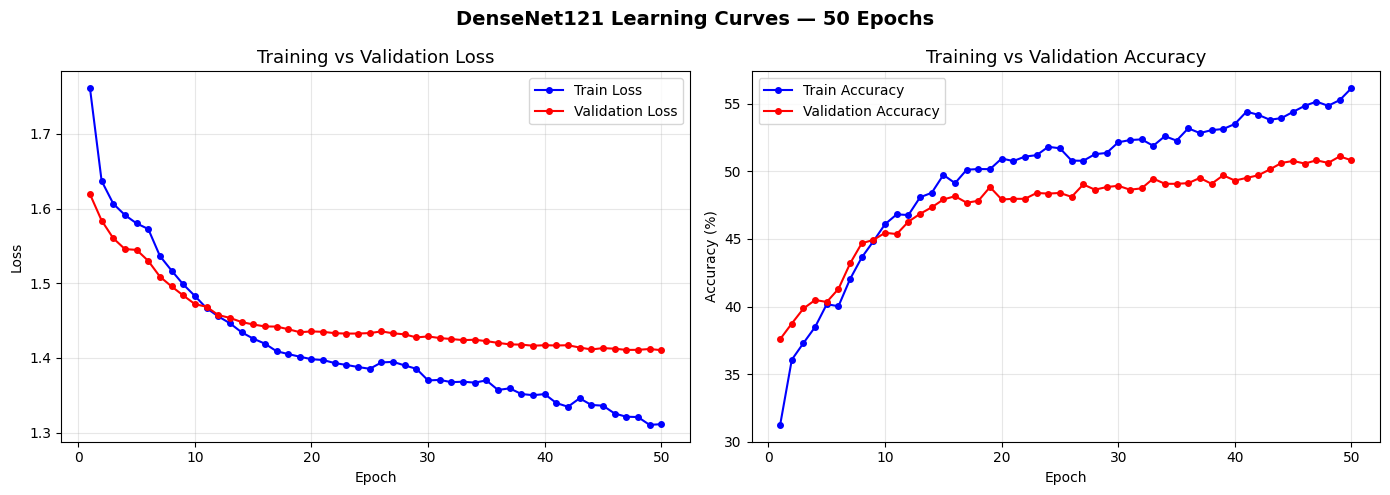

✅ Learning curves saved: learning_curves.png


In [68]:
import matplotlib.pyplot as plt

# Extract data from history dictionary
train_losses = history['train_loss']
val_losses   = history['val_loss']
train_accs   = history['train_acc']
val_accs     = history['val_acc']

#Plot Training & Validation Loss and Accuracy curves
epochs_range = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss Curve ---
ax1.plot(epochs_range, train_losses, 'b-o', label='Train Loss',      markersize=4)
ax1.plot(epochs_range, val_losses,   'r-o', label='Validation Loss', markersize=4)
ax1.set_title('Training vs Validation Loss', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Accuracy Curve ---
ax2.plot(epochs_range, train_accs, 'b-o', label='Train Accuracy',      markersize=4)
ax2.plot(epochs_range, val_accs,   'r-o', label='Validation Accuracy', markersize=4)
ax2.set_title('Training vs Validation Accuracy', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'DenseNet121 Learning Curves — {len(train_losses)} Epochs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/learning_curves.png', dpi=150)
plt.show()
print("✅ Learning curves saved: learning_curves.png")

/tmp/ipykernel_5203/2715400745.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Pneumonia       0.63      0.50      0.56       345
Cardiomegaly       0.58      0.83      0.68       345
Pneumothorax       0.51      0.40      0.45       345
        Mass       0.57      0.53      0.55       345
   Emphysema       0.61      0.70      0.65       345
 Atelectasis       0.47      0.44      0.45       345

    accuracy                           0.57      2070
   macro avg       0.56      0.57      0.56      2070
weighted avg       0.56      0.57      0.56      2070



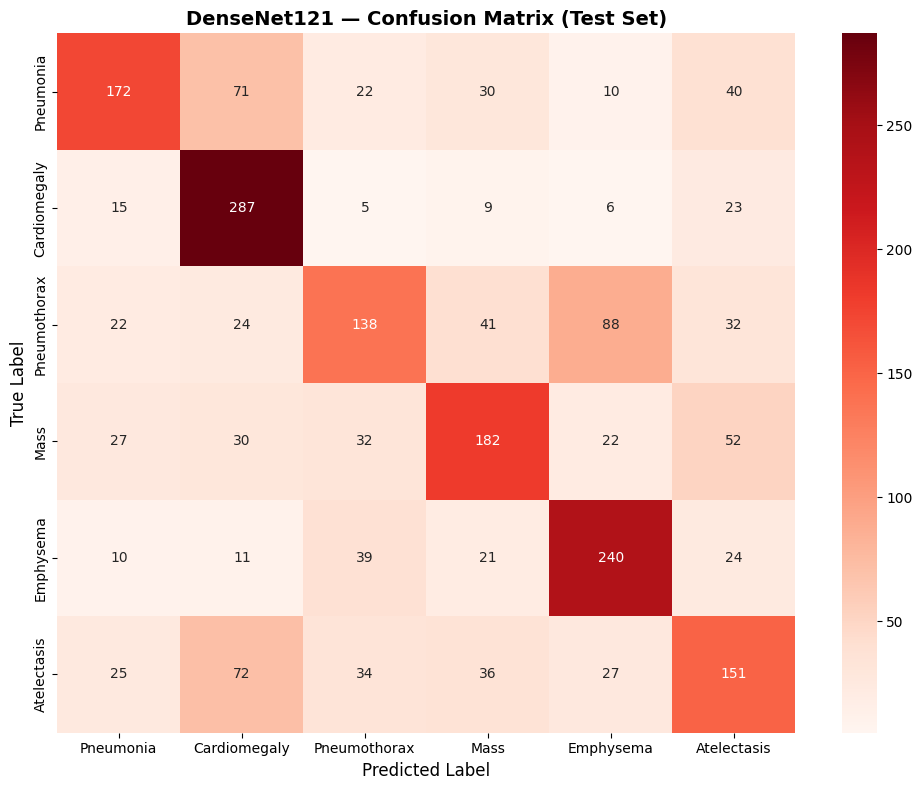

✅ Confusion matrix saved!


In [70]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch.cuda.amp import autocast # Import autocast

# Load best saved model weights
loaded_checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(loaded_checkpoint['model_state_dict'])
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        with autocast():
            outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=SELECTED_DISEASES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=SELECTED_DISEASES, yticklabels=SELECTED_DISEASES, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('DenseNet121 — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

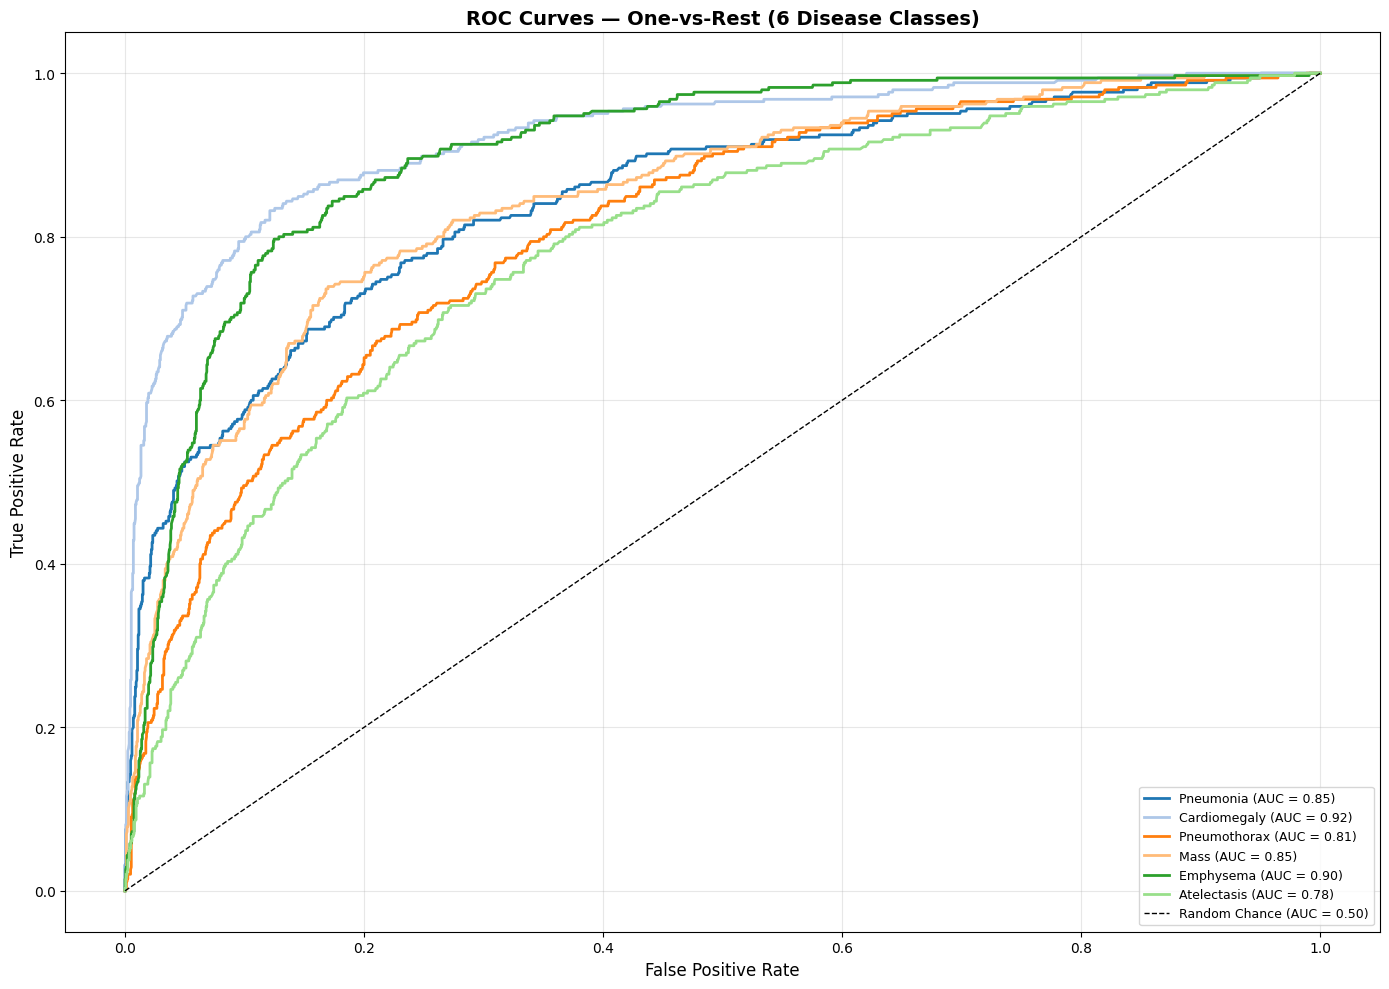

 ROC curves saved: roc_curves.png

AUC closer to 1.0 = model is better at detecting that disease.


In [71]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Convert to numpy arrays if they aren't already (important for slicing)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Binarize labels for One-vs-Rest ROC
y_true_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(14, 10))
colors_roc = plt.cm.tab20.colors

for i, class_name in enumerate(SELECTED_DISEASES):
    # Get ROC curve for this class vs all others
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc      = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors_roc[i], lw=2,
             label=f'{class_name} (AUC = {roc_auc:.2f})')

# Plot the random-chance diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance (AUC = 0.50)')

plt.title(f'ROC Curves — One-vs-Rest ({len(SELECTED_DISEASES)} Disease Classes)', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate',  fontsize=12)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150)
plt.show()
print(" ROC curves saved: roc_curves.png")
print("\nAUC closer to 1.0 = model is better at detecting that disease.")

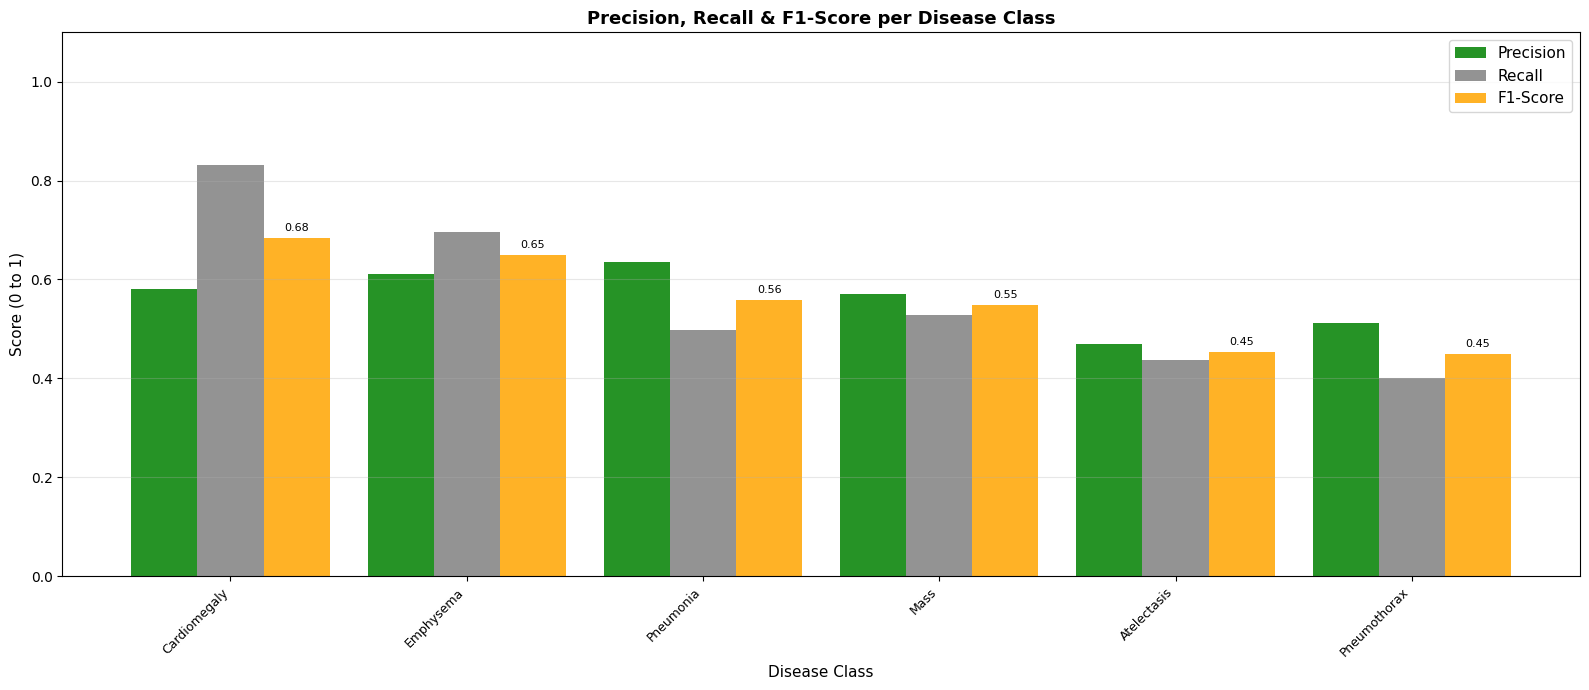

✅ F1-score chart saved: f1_scores.png


In [72]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Calculate F1, Precision, and Recall for each class
f1_scores  = f1_score(all_labels, all_preds, average=None)
precisions = precision_score(all_labels, all_preds, average=None, zero_division=0)
recalls    = recall_score(all_labels, all_preds, average=None, zero_division=0)

# Sort by F1 score for easier reading
sorted_idx  = np.argsort(f1_scores)[::-1]
sorted_cls  = [SELECTED_DISEASES[i] for i in sorted_idx]
sorted_f1   = f1_scores[sorted_idx]
sorted_prec = precisions[sorted_idx]
sorted_rec  = recalls[sorted_idx]

x     = np.arange(len(SELECTED_DISEASES))
width = 0.28

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width, sorted_prec, width, label='Precision', color='green',  alpha=0.85)
bars2 = ax.bar(x,         sorted_rec,  width, label='Recall',    color='gray', alpha=0.85)
bars3 = ax.bar(x + width, sorted_f1,   width, label='F1-Score',  color='orange',   alpha=0.85)

ax.set_title('Precision, Recall & F1-Score per Disease Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Disease Class', fontsize=11)
ax.set_ylabel('Score (0 to 1)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(sorted_cls, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# Add value labels on top of F1 bars
for bar in bars3:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/f1_scores.png', dpi=150)
plt.show()
print("✅ F1-score chart saved: f1_scores.png")

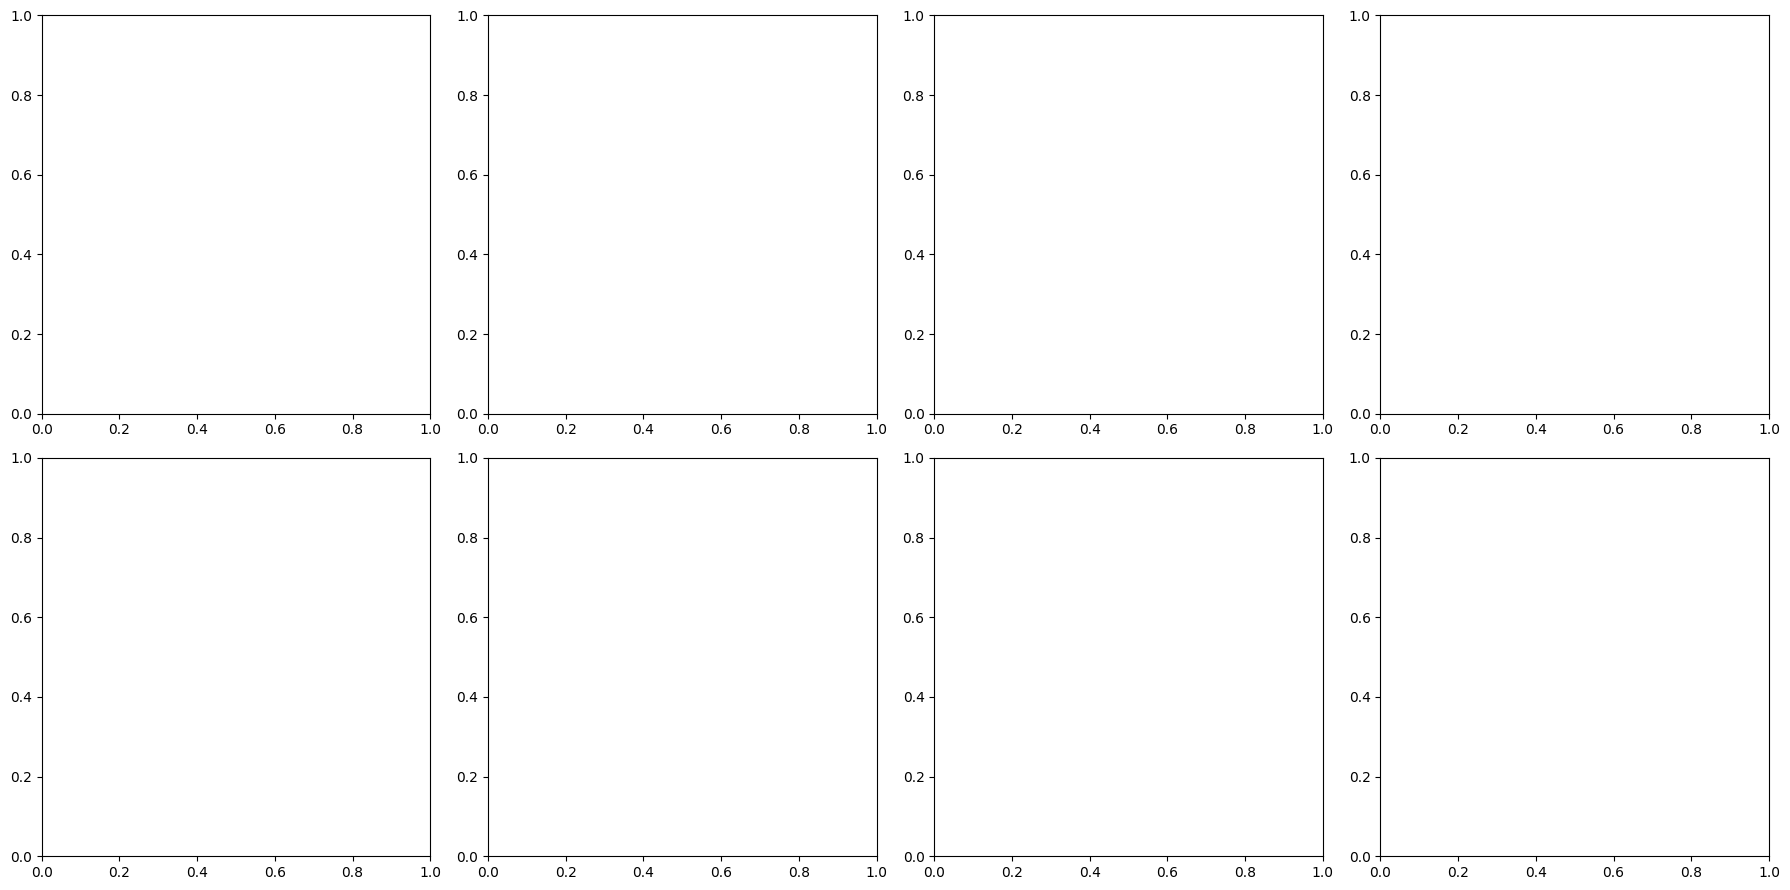

Done


In [73]:
# install
import sys
!{sys.executable} -m pip install grad-cam --quiet

# imports
import os, torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# config
IMG_SIZE = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

# 🔥 SET THIS PATH CORRECTLY
image_root = "/content/dataset/images"   # <-- CHANGE if needed

# transform
valtest_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# target layer
target_layer = model.features[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

# plot
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

count = 0

for idx in range(len(test_df)):
    if count >= 8:
        break

    try:
        row = test_df.iloc[idx]

        img_name = row["Image Index"]
        label = int(row["label"])

        img_path = os.path.join(image_root, img_name)
        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))

        rgb_img = np.array(img).astype(np.float32) / 255.0
        input_tensor = valtest_transform(img).unsqueeze(0).to(device)

        targets = [ClassifierOutputTarget(label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        axes[count].imshow(visualization)
        axes[count].set_title(f"Label: {label}")
        axes[count].axis("off")

        count += 1

    except:
        continue

plt.tight_layout()
plt.savefig("/content/gradcam_heatmaps.png", dpi=150)
plt.show()

print("Done")

In [74]:
import shutil
from sklearn.metrics import accuracy_score

# Create a folder on Drive to store all results
results_drive = '/content/drive/MyDrive/X_Ray_Dataset/training_results/'
os.makedirs(results_drive, exist_ok=True)

# List of all saved plots
plots = [
    '/content/distribution_before.png',
    '/content/distribution_after.png',
    '/content/sample_grid.png',
    '/content/learning_curves.png',
    '/content/confusion_matrix.png',
    '/content/roc_curves.png',
    '/content/f1_scores.png',
    '/content/gradcam_heatmaps.png',
]

for plot_path in plots:
    if os.path.exists(plot_path):
        shutil.copy(plot_path, results_drive)
        print(f"✅ Copied: {os.path.basename(plot_path)}")
    else:
        print(f"Not found: {plot_path}")

print(f"\nAll results saved to Drive: {results_drive}")
print(f" Model saved at: {SAVE_PATH}")

# Retrieve missing variables for summary
current_batch_size = train_loader.batch_size
# best_val_loss was not explicitly tracked, but we can get the loss from the best_epoch
current_best_val_loss = val_losses[best_epoch - 1]

# Calculate test accuracy from previously computed all_labels and all_preds
test_acc = accuracy_score(all_labels, all_preds) * 100

print("\n========== FINAL TRAINING SUMMARY ==========")
print(f"Dataset     : NIH ChestX-ray14 (filtered)")
print(f"Classes     : {NUM_CLASSES} disease classes")
print(f"Train size  : {len(train_df)} images")
print(f"Val size    : {len(val_df)} images")
print(f"Test size   : {len(test_df)} images")
print(f"Epochs      : {EPOCHS}")
print(f"Batch size  : {current_batch_size}")
print(f"Best Val Loss: {current_best_val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print("============================================")

✅ Copied: distribution_before.png
Not found: /content/distribution_after.png
✅ Copied: sample_grid.png
✅ Copied: learning_curves.png
✅ Copied: confusion_matrix.png
✅ Copied: roc_curves.png
✅ Copied: f1_scores.png
✅ Copied: gradcam_heatmaps.png

All results saved to Drive: /content/drive/MyDrive/X_Ray_Dataset/training_results/
 Model saved at: /content/drive/MyDrive/modeloutput/DenseNet121V556.pt

========== FINAL TRAINING SUMMARY ==========
Dataset     : NIH ChestX-ray14 (filtered)
Classes     : 6 disease classes
Train size  : 9660 images
Val size    : 2070 images
Test size   : 2070 images
Epochs      : 50
Batch size  : 96
Best Val Loss: 1.4481
Test Accuracy: 56.52%
